# 步骤 03 · 第一次 FFT —— 项目里最重要的一次失败

**这一节的产出：图 3a（频谱全景）+ 图 3b（0–500 Hz 放大，带理论频率标注）。**

## 我们为什么走到这一步

前两节确立了两件事：

1. **信息在"节奏"里。** 外圈故障 = 每秒 105.9 次冲击。你在图 1 上数出 21 簇/0.2 秒，亲手验证过。
2. **时域统计量看不见节奏。** 打乱信号顺序，三个指标纹丝不动 —— 你在练习 2 里验证过。

所以现在要换一个**能看见节奏**的工具：**FFT**。

## 这一节会发生什么

我们会算出理论频率（BPFO 105.9、BPFI 159.9、BSF 139.2 Hz），在频谱上画三条竖线指过去，然后看那里有什么。

**剧透：你会看到峰。而且这比"什么都没有"更糟糕。**

因为那些峰**在健康轴承的频谱里也有**，而且一样高。如果你手头没有健康记录做对照，你会对着一个好轴承宣布"内圈故障"。

这一节真正教的东西是：**"看到了一个峰" 和 "拿到了一个证据" 完全是两回事。**

---
## 1. 什么是频谱

FFT 把信号从**时域**搬到**频域**：

| | 横轴 | 纵轴 | 回答的问题 |
|---|---|---|---|
| 时域（图 1） | 时间 (s) | 加速度 (g) | 每一瞬间抖了多少 |
| 频域（图 3） | 频率 (Hz) | 幅值 (g) | 哪些节奏在里面，各占多强 |

**同一份数据的两种看法，信息量完全相同** —— FFT 是可逆的，从频谱能一模一样地变回波形。它没有增加信息，只是**换了个角度摆放**，让"节奏"这件事从看不见变成看得见。

### 频率分辨率：你能分清多细的频率

$$\Delta f = \frac{f_s}{N}$$

我们有 120976 个点、采样率 12000 Hz，所以 **Δf ≈ 0.099 Hz**。意思是频谱上相邻两根谱线相差 0.099 Hz —— 足够分清 105.9 和 106.0 了。

**记住这个权衡**：想要更细的频率分辨率，就得录更长的时间。没有别的办法。10 秒给你 0.1 Hz，1 秒只能给你 1 Hz。

> 这条限制是物理性的，不是算法不够好。直觉上也说得通：**你想区分"每秒 105.9 次"和"每秒 106.0 次"这两个节奏，就必须观察足够久，久到两者的差别累积成看得出的错位。**

### 采样率决定你能看到多高的频率

频谱的上限是 $f_s/2 = 6000$ Hz，叫**奈奎斯特频率**（Nyquist frequency）。

道理很直白：**一个周期你至少要采到两个点**（一上一下），才能知道它在振荡。每秒采 12000 个点，最多能描述每秒 6000 次的振荡。比这更快的成分不但看不见，还会**伪装成低频出现在谱里**（这叫混叠，aliasing）——这就是为什么上一节我们必须把 48 kHz 的健康记录规规矩矩地降采样，而不是每隔 4 个点取一个。

---
## 2. 准备

In [18]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import cwru_io

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

normal = cwru_io.load_baseline(DATA / "normal_1hp_98.mat",    name="Healthy")
outer  = cwru_io.load(DATA / "OR007at6_1hp_131.mat", name="Outer race")
inner  = cwru_io.load(DATA / "IR007_1hp_106.mat",    name="Inner race")
ball   = cwru_io.load(DATA / "B007_1hp_119.mat",     name="Ball")

signals = [normal, outer, inner, ball]

# 四条记录长度略有不同。频率分辨率 = fs/N，长度不同分辨率就不同，
# 谱线粗细不一样没法横向比 —— 所以统一截到最短的那条。
N = min(len(s.x) for s in signals)
print(f"统一取 {N} 点 = {N/cwru_io.FS:.2f} 秒")
print(f"频率分辨率 {cwru_io.FS/N:.3f} Hz，上限（奈奎斯特）{cwru_io.FS/2} Hz")
print()
for s in signals:
    ff = s.fault_freqs()
    print(f"{s.name:<12} {s.rpm:.0f} rpm   "
          f"BPFO {ff['BPFO']:.1f}   BPFI {ff['BPFI']:.1f}   BSF {ff['BSF']:.1f} Hz")

统一取 120976 点 = 10.08 秒
频率分辨率 0.099 Hz，上限（奈奎斯特）6000.0 Hz

Healthy      1772 rpm   BPFO 105.9   BPFI 159.9   BSF 139.2 Hz
Outer race   1773 rpm   BPFO 105.9   BPFI 160.0   BSF 139.3 Hz
Inner race   1772 rpm   BPFO 105.9   BPFI 159.9   BSF 139.2 Hz
Ball         1772 rpm   BPFO 105.9   BPFI 159.9   BSF 139.2 Hz


---
## 3. 写 FFT，并验证它

三行就能算出频谱，但有两个细节不能漏。

In [19]:
def spectrum(x, fs, n=None):
    # 返回 (频率轴, 幅值谱)。幅值的单位和输入一样（g）。
    n = n or len(x)
    x = x[:n] - x[:n].mean()          # 去直流，否则 0 Hz 一根巨峰
    win = np.hanning(n)              # 加窗，见下面说明
    X = np.fft.rfft(x * win)
    A = np.abs(X) / n * 4             # 归一化：/n 是 FFT 定义，*2 是单边谱，
                                      # 再 *2 补偿汉宁窗 0.5 的增益 -> 共 *4
    f = np.fft.rfftfreq(n, 1 / fs)
    return f, A


# 用已知答案验证：1.0 g 的 50 Hz + 0.5 g 的 200 Hz
fs = 12000
t = np.arange(12000) / fs
test = 1.0 * np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 200 * t)
f, A = spectrum(test, fs)

for f0 in (50, 200):
    peak = A[np.abs(f - f0) <= 2].max()
    print(f"  {f0:3d} Hz 处测得幅值 {peak:.3f}")
print("\n应该分别得到 ≈1.00 和 ≈0.50 —— 对上了说明归一化没写错")

   50 Hz 处测得幅值 1.000
  200 Hz 处测得幅值 0.500

应该分别得到 ≈1.00 和 ≈0.50 —— 对上了说明归一化没写错


### 细节一：`rfft` 而不是 `fft`

真实信号的频谱是**对称**的（负频率是正频率的镜像），算出来一半是冗余的。`rfft`（real FFT）只算有用的那一半，**省一半时间和内存**。`rfftfreq` 配套生成对应的频率轴。

### 细节二：加窗（windowing）

`np.hanning(n)` 生成一条两端为 0、中间鼓起的曲线，乘到信号上，把信号**两端平滑地压到零**。

**为什么要这么做？** FFT 在数学上假设你给它的这段信号是**无限循环**的 —— 它把 10 秒的记录想象成首尾相接、无限重复。但你的信号首尾通常对不上，接缝处会出现一个人为的"突变"。**那个不存在的突变会在频谱里散出一大片假的能量**，把真实的峰淹掉。这叫**频谱泄漏**（spectral leakage）。

加窗把两端压到零，接缝就平滑了，泄漏大幅减少。

代价是幅值会被压低（汉宁窗平均只保留一半能量），所以后面要乘 2 补偿回来 —— 这就是 `* 4` 里的那个 2 的来历。

> **上面那个验证格子就是在查这件事。** 如果归一化写错了，50 Hz 处会测出 0.5 或 2.0 而不是 1.0。不先验证就直接跑真实数据，你根本不知道幅值该不该信。

---
## 4. 图 3a：频谱全景

先看全貌：0 到 6000 Hz，四条记录各一行。

**纵轴用对数刻度**（`semilogy`）。因为幅值跨了三四个数量级，线性刻度下小的那些全被压成一条贴着零的直线，什么也看不见。对数刻度让"0.001 和 0.0001 的差别"和"0.1 和 0.01 的差别"在视觉上一样明显。

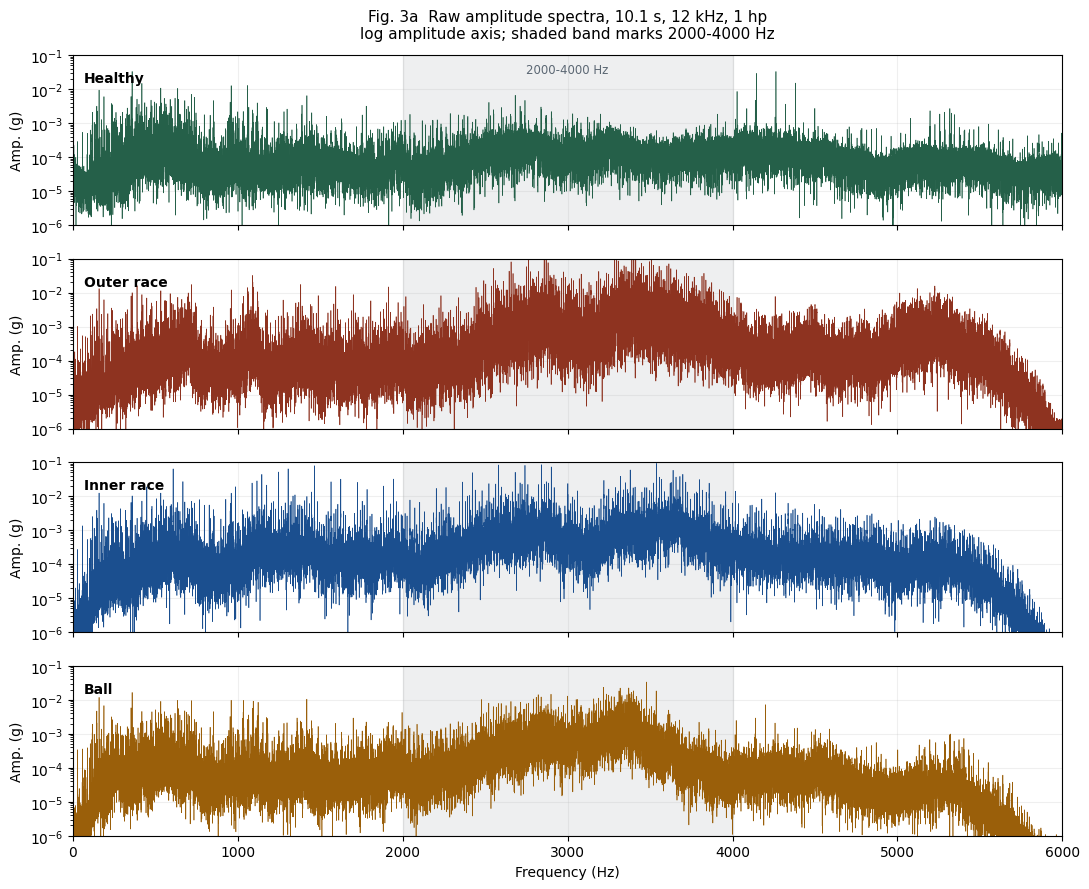

In [20]:
COLORS = {"Healthy": "#256049", "Outer race": "#8E3320",
          "Inner race": "#1B4F8F", "Ball": "#9A5F0A"}

specs = {s.name: spectrum(s.x, s.fs, N) for s in signals}

fig3a, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True, sharey=True)

for ax, s in zip(axes, signals):
    f, A = specs[s.name]
    ax.semilogy(f, A, linewidth=0.45, color=COLORS[s.name])
    ax.axvspan(2000, 4000, color="#5B6773", alpha=0.10)   # 标出 2-4 kHz
    ax.set_ylabel("Amp. (g)")
    ax.set_ylim(1e-6, 1e-1)
    ax.grid(alpha=0.2)
    ax.text(0.011, 0.84, s.name, transform=ax.transAxes,
            fontsize=10, fontweight="bold")

axes[0].text(3000, 3e-2, "2000-4000 Hz", fontsize=8.5,
             color="#5B6773", ha="center")
axes[-1].set_xlabel("Frequency (Hz)")
axes[-1].set_xlim(0, 6000)
axes[0].set_title("Fig. 3a  Raw amplitude spectra, 10.1 s, 12 kHz, 1 hp\n"
                  "log amplitude axis; shaded band marks 2000-4000 Hz",
                  fontsize=11, pad=12)
fig3a.tight_layout()
plt.show()

### 读图 3a

**健康那条（第一行）**：整体是一条大致平坦的噪声底，上面插着一些离散的窄线 —— 低频段有一批，4100–4300 Hz 附近有几根特别高的。那几根窄线就是能量表里"健康记录 36.8% 的能量落在 4000–5000 Hz"的来源。

**但关键是健康那条在 2000–4000 Hz 完全平坦，没有鼓包。**

**三条故障记录**：在灰色阴影那一带（2000–4000 Hz）鼓起一大片**又宽又乱**的能量，把噪声底整个抬起来了一两个数量级。

注意"宽鼓包"和"窄线"的区别 —— 健康记录高频处那几根是**孤立的细线**（某个固定频率的持续振荡），故障记录是**连绵的一片**。这两者的成因完全不同，下面就讲。

这个"鼓包"就是**结构共振**。每次滚珠碾过坑，都像用小锤敲了一下轴承座，轴承座按自己的固有频率"嗡"地响。响的音高只跟结构有关，所以每次都在同一个频段 —— 于是 10 秒里上千次敲击的响声叠成了这一大片。

**注意它有多宽。** 它不是一根细峰，是从 2000 到 4000 Hz 连绵一片。这很关键：**冲击是"宽带"的**，一次极短的撞击会激起一整片频率，而不是单一频率。

> 一个必须说清的细节：健康那条记录是从 48 kHz 降采样过来的，经过了抗混叠滤波器；三条故障记录是原生 12 kHz。所以在很靠近 6000 Hz 的地方，两者不完全是同等条件。中间频段不受影响，我们关心的 2000–4000 Hz 也不受影响，但写报告时应当注明。

---
## 5. 用数字确认："能量到底在哪"

眼睛看着像，不算数。把每个频段占总能量的百分比算出来。

In [21]:
BANDS = [(0, 500), (500, 1000), (1000, 2000), (2000, 3000),
         (3000, 4000), (4000, 5000), (5000, 6000)]

print("各频段能量占比 (%)")
print(f"{'':12}" + "".join(f"{f'{a}-{b}':>10}" for a, b in BANDS))
print("-" * 82)
energy = {}
for s in signals:
    f, A = specs[s.name]
    total = np.sum(A ** 2)
    row = [100 * np.sum(A[(f >= a) & (f < b)] ** 2) / total for a, b in BANDS]
    energy[s.name] = row
    print(f"{s.name:<12}" + "".join(f"{v:>10.1f}" for v in row))

print("\n\n故障 / 健康 的能量倍数（同一频段内直接相除）")
print(f"{'':12}" + "".join(f"{f'{a}-{b}':>10}" for a, b in BANDS))
print("-" * 82)
fh, Ah = specs["Healthy"]
for s in signals[1:]:
    f, A = specs[s.name]
    row = [np.sum(A[(f >= a) & (f < b)] ** 2) / np.sum(Ah[(fh >= a) & (fh < b)] ** 2)
           for a, b in BANDS]
    print(f"{s.name:<12}" + "".join(f"{v:>10.1f}" for v in row))

各频段能量占比 (%)
                 0-500  500-1000 1000-2000 2000-3000 3000-4000 4000-5000 5000-6000
----------------------------------------------------------------------------------
Healthy           29.4      13.8       6.4       7.4       4.7      36.8       1.5
Outer race         0.2       0.3       0.7      29.3      68.1       0.3       1.2
Inner race         0.6       4.3      15.5      36.9      41.2       1.3       0.1
Ball               1.9       2.5       2.2      19.4      73.3       0.5       0.0


故障 / 健康 的能量倍数（同一频段内直接相除）
                 0-500  500-1000 1000-2000 2000-3000 3000-4000 4000-5000 5000-6000
----------------------------------------------------------------------------------
Outer race         0.5       2.1      10.7     379.2    1382.1       0.8      74.0
Inner race         0.5       7.4      57.0     117.0     205.0       0.8       2.0
Ball               0.4       1.0       1.8      13.9      82.4       0.1       0.2


### 这两张表说了什么

**故障把能量搬家了。**

| | 0–500 Hz 占比 | 2000–4000 Hz 占比 |
|---|---|---|
| Healthy | 29.4 % | 12.1 % |
| Outer race | **0.2 %** | **97.4 %** |
| Inner race | 0.6 % | 78.1 % |
| Ball | 1.9 % | 92.7 % |

外圈故障有 **97.4%** 的能量挤在 2000–4000 Hz；而理论说故障频率在 105.9 Hz 的那个低频段，只剩 **0.2%**。

第二张表更直接：外圈故障在 3000–4000 Hz 的能量是健康的 **1382 倍**，而在 0–500 Hz 只有健康的 **0.5 倍** —— **比健康的还少。**

**所以你要找的东西，确实不在你要去找的地方。** 但它没有消失，它在 30 倍远的高频处。

这正是下一节（时频图）和第 05 节（包络谱）的全部动机。

---
## 6. 图 3b：放大到 0–500 Hz，看理论频率处有什么

现在做这个项目原本要做的事：放大低频段，在 BPFO / BPFI / BSF 处画竖线。

**关键在于四条记录一起画，健康那条必须在场。** 没有对照组，你会把噪声当成发现 —— 这一节接下来就证明这一点。

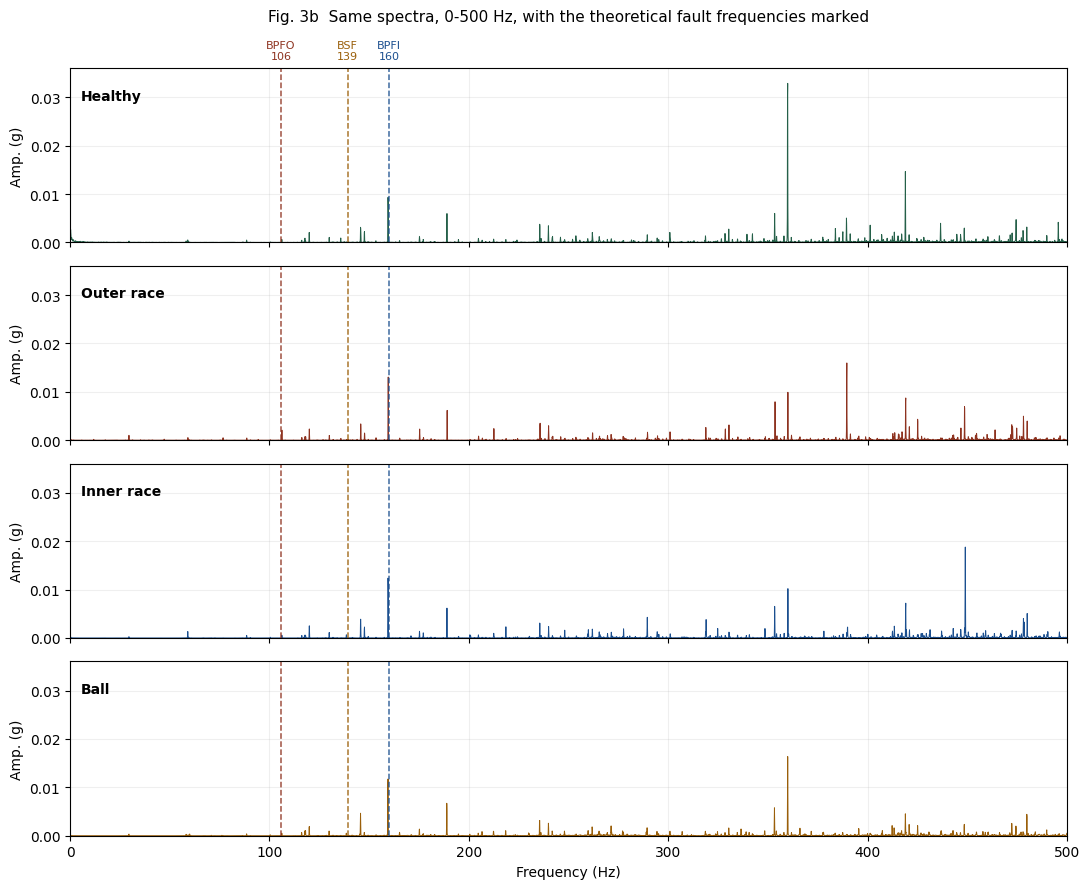

In [22]:
fig3b, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True, sharey=True)

LINES = [("BPFO", "#8E3320"), ("BPFI", "#1B4F8F"), ("BSF", "#9A5F0A")]

for ax, s in zip(axes, signals):
    f, A = specs[s.name]
    m = f <= 500
    ax.plot(f[m], A[m], linewidth=0.7, color=COLORS[s.name])

    ff = s.fault_freqs()
    for k, c in LINES:
        ax.axvline(ff[k], color=c, linestyle="--", linewidth=1.1, alpha=0.85)

    ax.set_ylabel("Amp. (g)")
    ax.set_ylim(0, 0.036)
    ax.grid(alpha=0.2)
    ax.text(0.011, 0.82, s.name, transform=ax.transAxes,
            fontsize=10, fontweight="bold")

# 只在第一行标出三条线各是谁
ff = signals[0].fault_freqs()
for k, c in LINES:
    axes[0].text(ff[k], 0.0375, f"{k}\n{ff[k]:.0f}", color=c, fontsize=8,
                 ha="center", va="bottom", linespacing=1.15)

axes[-1].set_xlabel("Frequency (Hz)")
axes[-1].set_xlim(0, 500)
axes[0].set_title("Fig. 3b  Same spectra, 0-500 Hz, with the theoretical fault "
                  "frequencies marked", fontsize=11, pad=34)
fig3b.tight_layout()
plt.show()

---
## 7. 看图 3b —— 这一节真正的发现

先说你**没有**看到的：竖线上并没有拔地而起的尖峰。外圈那条在 BPFO 处也没有任何醒目的东西。

但你也**不是**看到一片空白。低频段有一堆峰。问题是 —— **它们是谁？**

In [23]:
print("=== 0-500 Hz 内最强的 6 根峰，四条记录并排看 ===\n")
for s in signals:
    f, A = specs[s.name]
    m = (f > 2) & (f < 500)
    fm, Am = f[m], A[m]
    picked = []
    for i in np.argsort(Am)[::-1]:
        if all(abs(fm[i] - q) > 4 for q, _ in picked):
            picked.append((fm[i], Am[i]))
        if len(picked) == 6:
            break
    print(f"  {s.name:<12}" + "  ".join(f"{q:5.1f}({a:.4f})" for q, a in picked))

print("\n\n=== 三个理论故障频率处的幅值，横向比较 (g) ===\n")
print(f"{'':12}{'BPFO 105.9':>13}{'BPFI 159.9':>13}{'BSF 139.2':>13}{'整段RMS':>11}")
print("-" * 62)
for s in signals:
    f, A = specs[s.name]
    vals = [A[np.abs(f - f0) <= 1.0].max() for f0 in (105.9, 159.9, 139.2)]
    rms = np.sqrt(np.mean(s.x[:N] ** 2))
    print(f"{s.name:<12}" + "".join(f"{v:>13.5f}" for v in vals) + f"{rms:>11.4f}")

=== 0-500 Hz 内最强的 6 根峰，四条记录并排看 ===

  Healthy     360.0(0.0329)  419.0(0.0147)  159.5(0.0093)  353.4(0.0060)  189.1(0.0060)  389.4(0.0050)
  Outer race  389.6(0.0160)  159.6(0.0131)  360.1(0.0099)  419.2(0.0087)  353.6(0.0079)  448.7(0.0069)
  Inner race  449.0(0.0188)  159.5(0.0124)  360.1(0.0102)  419.2(0.0072)  353.4(0.0065)  189.1(0.0062)
  Ball        360.0(0.0164)  159.5(0.0117)  189.0(0.0067)  353.3(0.0058)  145.7(0.0046)  419.0(0.0045)


=== 三个理论故障频率处的幅值，横向比较 (g) ===

               BPFO 105.9   BPFI 159.9    BSF 139.2      整段RMS
--------------------------------------------------------------
Healthy           0.00062      0.00932      0.00010     0.0617
Outer race        0.00207      0.01305      0.00016     0.5921
Inner race        0.00057      0.01237      0.00066     0.2928
Ball              0.00051      0.01172      0.00052     0.1391


### 发现一：最强的那些峰，四条记录**完全一样**

360.0、419.0、159.5、353.4、189.1 Hz —— 这几根在**健康记录里也有**，而且往往还更高。

它们不是轴承故障，是**这台机器本身**：360 Hz 正好是市电 60 Hz 的 6 倍频，其余几根是电机的电磁和机械谱线。它们和轴承坏不坏毫无关系。

### 发现二：BPFI 处那根峰，是个陷阱

看那张幅值表的 BPFI 一列：

| | BPFI 159.9 Hz 处幅值 |
|---|---|
| Healthy | 0.0093 |
| Outer race | 0.0131 |
| Inner race | 0.0124 |
| Ball | 0.0117 |

**四条记录全都有，高度差不多，健康的也不例外。**

这是全节最重要的一句话：

> **如果你手上只有内圈故障那条记录，你会看到 BPFI 处有一根 0.0124 g 的峰，兴高采烈地宣布"内圈故障确认"。而同一套推理用在健康轴承上，会给出同样的结论。**

那根峰实际上是 159.5 Hz 的机器谱线，恰好落在 BPFI = 159.9 Hz 旁边。**纯属巧合。**

### 发现三：BPFO 处外圈确实高一些，但没有用

外圈在 BPFO 处是 0.00207 g，健康是 0.00062 g —— **3.3 倍**，看起来是个信号。

但看最后一列：外圈整段的 RMS 是 **0.5921 g**。那根峰占整体的 **0.35%**。

在图 3b 的线性坐标上，这根峰和它周围的噪声毫无区别；而且它比同一张图里那些机器谱线小了一个数量级。**你没有任何理由把它挑出来说"就是它"。**

---
## 8. 所以第三堵墙长什么样

路线图原本预期的是"竖线上什么都没有"。**真实情况比那更棘手：**

| | 实际情况 |
|---|---|
| 竖线处有峰吗 | 有 |
| 那些峰是故障造成的吗 | **不是**，健康记录里同样有 |
| 能不能靠它判断 | **不能，而且会误判** |
| 故障的能量在哪 | 2000–4000 Hz，占 97.4% |

**"没有证据"和"有一个骗人的证据"，后者危险得多。**

这一节最该带走的方法论：

> **对照组不是形式主义。** 如果我们只下载了三个故障文件、没下健康文件，这个项目会在这里走上歧途 —— 而且是带着"我看到峰了"的信心走上歧途。

### 为什么会这样：物理解释

回到图 1 那个画面。滚珠碾过坑，是一次**极短、极猛**的撞击 —— 持续可能不到 0.1 毫秒。

**一次极短的撞击，在频域里是"一大片"而不是"一根线"。** 时间上越尖锐的东西，频率上摊得越宽。（这是傅里叶变换最基本的性质之一：时域和频域的"宽窄"互为倒数。）

所以每次撞击的能量，被摊到了 2000–4000 Hz 这一整片共振区，而**不是**集中到 105.9 Hz 那一根线上。

**105.9 Hz 是撞击"多久来一次"，不是撞击本身的频率。**

这个区别是整个项目的枢纽，值得再读一遍：

- 撞击**本身**的频率成分 → 2000–4000 Hz 的宽带共振
- 撞击**发生的节奏** → 105.9 Hz

直接做 FFT，看到的是前者。**我们要的是后者。**

### 所以下一步

如果 105.9 Hz 这个节奏真的存在，它应该表现为：**2000–4000 Hz 那片能量，每秒钟忽强忽弱 105.9 次。**

能量不是恒定的，是一阵一阵的。**这个"一阵一阵"就是我们要的信息。**

- **步骤 04** 用时频图把这件事**看见** —— 能量随时间的起伏
- **步骤 05** 用包络谱把这个起伏的节奏**量出来** —— 那根 105.9 Hz 的峰终于会出现

---
## 9. 保存

In [24]:
FIGURES.mkdir(exist_ok=True)
for fig, name in [(fig3a, "fig03a_spectrum_full.png"),
                  (fig3b, "fig03b_spectrum_zoom.png")]:
    p = FIGURES / name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print("已保存:", p)

# 能量占比表也存一份，报告的 Results 要用
p = FIGURES / "table02_band_energy.txt"
with open(p, "w", encoding="utf-8") as fh:
    fh.write("Share of total spectral energy per band (%)\n\n")
    fh.write(f"{'':14}" + "".join(f"{f'{a}-{b}':>10}" for a, b in BANDS) + "\n")
    fh.write("-" * 84 + "\n")
    for s in signals:
        fh.write(f"{s.name:<14}" + "".join(f"{v:>10.1f}" for v in energy[s.name]) + "\n")
    fh.write(f"\n{N} samples at {cwru_io.FS} Hz, Hann window, 1 hp load.\n")
print("已保存:", p)

已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig03a_spectrum_full.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig03b_spectrum_zoom.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\table02_band_energy.txt


---
## 10. 自己动手

**练习 1（看频谱泄漏）.** 把 `spectrum` 里的 `win = np.hanning(n)` 改成 `win = np.ones(n)`（等于不加窗），重跑第 4 节。图 3a 的低频段会变糊 —— 那就是泄漏。改回来。

**练习 2（看分辨率的代价）.** 在第 2 节把 `N` 改成 `12000`（只用 1 秒），重跑第 4、6 节。频率分辨率从 0.099 Hz 变成 1.0 Hz，图 3b 里那些细峰会变成什么样？

**练习 3（重要，亲手证明那个陷阱）.** 假装你没有健康记录，只看内圈那一行图 3b。**你会不会宣布"BPFI 处有峰，内圈故障确认"？** 然后把健康那一行调出来对比。

**练习 4.** 在第 5 节的 `BANDS` 里加一段 `(2500, 3500)`，看外圈故障在这一小段里占多少能量。这个数字在步骤 06 选共振带时还会回来。

---
## 小结

| 做了 | 结论 |
|---|---|
| 写 FFT 并用已知信号验证归一化 | 实现正确 |
| 频谱全景（图 3a） | 故障能量集中在 2000–4000 Hz 的宽带共振 |
| 频段能量统计 | 外圈：97.4% 在 2–4 kHz，0–500 Hz 只剩 0.2%（比健康还低） |
| 0–500 Hz 放大（图 3b） | 有峰，但四条记录**共有**，是机器谱线 |
| BPFI 处那根峰 | **陷阱** —— 健康记录同样有，会导致误判 |
| 直接 FFT 能诊断吗 | **不能，而且会骗你** |

**关键认识**：105.9 Hz 是冲击**发生的节奏**，不是冲击**本身的频率**。直接 FFT 看到的是后者。

**下一步（步骤 04）**：短时傅里叶变换，把"2–4 kHz 的能量一阵一阵"这件事**画出来**。你会在时频图上看到周期性的竖条纹 —— 那就是被埋起来的节奏，第一次现身。